# Metadata gaps — share of individuals with a floruit period but no Cliopatria polity match, by century.

In [1]:
import random
import numpy as np
import polars as pl
import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/humans_clean.duckdb'

BORN_AFTER_CUTOFF       = 1995
CENTURY_MIN_INDIVIDUALS = 50
CENTURY_RANGE           = (-3000, 2000)

COLORS = {
    'missing': '#b5542a',
    'neutral': '#888888',
}

mpl.rcParams.update({
    'figure.dpi':         120,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.family':        'DejaVu Sans',
    'axes.labelsize':     11,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
})


## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)


## Individuals  (one row per Wikidata individual, with floruit period and birth/death years)

In [3]:
individuals = con.execute('''
    SELECT wikidata_id, birth_year, death_year, floruit_period_start
    FROM   individuals_floruit_period
''').pl()

print('shape:', individuals.shape)
individuals.head()


shape: (13003420, 4)


wikidata_id,birth_year,death_year,floruit_period_start
str,i64,i64,i64
"""Q101553124""",null,null,2015
"""Q101553254""",null,null,null
"""Q101553398""",1975,null,2005
"""Q101553548""",1947,null,1977
"""Q101553561""",null,null,null


## Cohort  (exclude individuals born after 1995 with no death year — their floruit period has not yet been established)

In [4]:
cohort = individuals.filter(
    pl.col('birth_year').is_null()
    | (pl.col('birth_year') <= BORN_AFTER_CUTOFF)
    | pl.col('death_year').is_not_null()
)
excluded = individuals.height - cohort.height

print('shape:', cohort.shape)
print(f'excluded: {excluded:,}')
cohort.head()


shape: (12643245, 4)
excluded: 360,175


wikidata_id,birth_year,death_year,floruit_period_start
str,i64,i64,i64
"""Q101553124""",null,null,2015
"""Q101553254""",null,null,null
"""Q101553398""",1975,null,2005
"""Q101553548""",1947,null,1977
"""Q101553561""",null,null,null


## Polity matches  (one row per individual × Cliopatria polity)

In [5]:
polity_matches = con.execute('''
    SELECT wikidata_id, polity_id, polity_name
    FROM   individuals_cliopatria
    WHERE  polity_name IS NOT NULL
''').pl()

print('shape:', polity_matches.shape)
polity_matches.head()


shape: (5065026, 3)


wikidata_id,polity_id,polity_name
str,i64,str
"""Q107522""",1385,"""Weimar Republic"""
"""Q107522041""",1389,"""Union of Soviet Socialist Repu…"
"""Q107522056""",1272,"""Venezuela"""
"""Q107522108""",1148,"""United States of America"""
"""Q107522122""",1590,"""Russian Federation"""


## Cohort flagged with has_polity_match and has_floruit

In [6]:
matched_individuals = (
    polity_matches.select('wikidata_id').unique()
    .with_columns(pl.lit(True).alias('has_polity_match'))
)

cohort_flagged = (
    cohort
    .join(matched_individuals, on='wikidata_id', how='left')
    .with_columns(
        pl.col('has_polity_match').fill_null(False),
        pl.col('floruit_period_start').is_not_null().alias('has_floruit'),
    )
)

print('shape:', cohort_flagged.shape)
cohort_flagged.head()


shape: (12643245, 6)


wikidata_id,birth_year,death_year,floruit_period_start,has_polity_match,has_floruit
str,i64,i64,i64,bool,bool
"""Q101553124""",null,null,2015,false,true
"""Q101553254""",null,null,null,false,false
"""Q101553398""",1975,null,2005,true,true
"""Q101553548""",1947,null,1977,true,true
"""Q101553561""",null,null,null,false,false


## Sanity check — polity-matched individuals without a floruit period

In [7]:
polity_matched_without_floruit = (
    cohort_flagged
    .filter(pl.col('has_polity_match') & ~pl.col('has_floruit'))
    .height
)

print(f'polity-matched individuals without a floruit period: {polity_matched_without_floruit:,}')


polity-matched individuals without a floruit period: 0


## Fig 1 — % of individuals with a floruit period but no polity match, by century of floruit start

In [8]:
share_without_polity_per_century = (
    cohort_flagged
    .filter(pl.col('has_floruit'))
    .with_columns(((pl.col('floruit_period_start') // 100) * 100).alias('century'))
    .filter(pl.col('century').is_between(*CENTURY_RANGE))
    .group_by('century')
    .agg([
        pl.len().alias('individuals'),
        pl.col('has_polity_match').sum().alias('with_polity'),
    ])
    .with_columns(
        ((1 - pl.col('with_polity') / pl.col('individuals')) * 100).alias('pct_without_polity')
    )
    .filter(pl.col('individuals') >= CENTURY_MIN_INDIVIDUALS)
    .sort('century')
)

print('shape:', share_without_polity_per_century.shape)
share_without_polity_per_century.head()


shape: (46, 4)


century,individuals,with_polity,pct_without_polity
i64,u32,u32,f64
-2600,69,17,75.362319
-2500,119,25,78.991597
-2400,57,9,84.210526
-2200,65,24,63.076923
-2100,62,13,79.032258


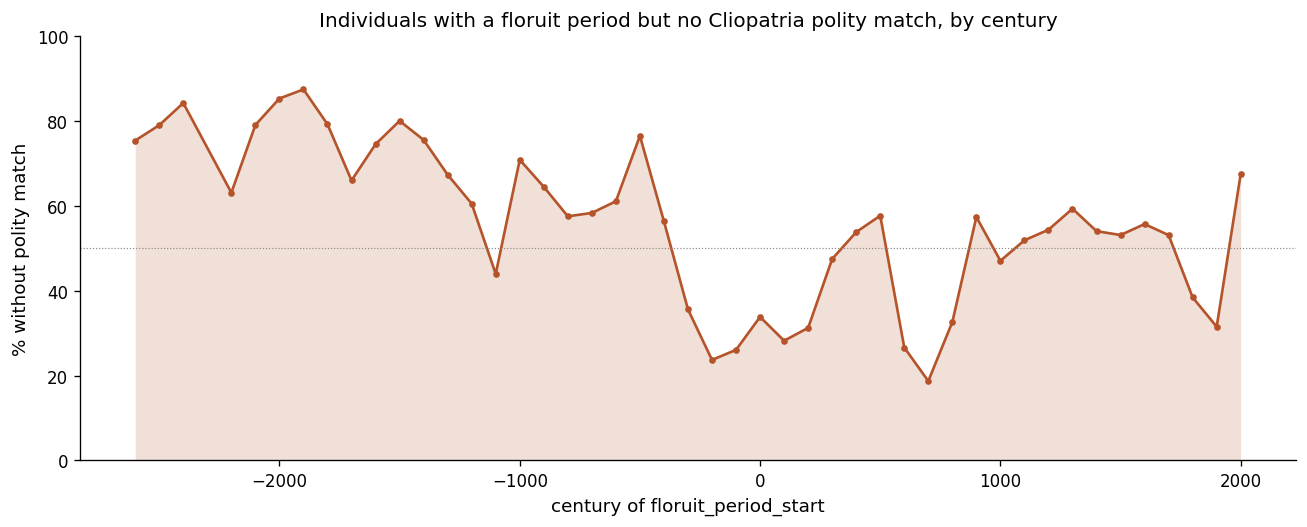

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))

centuries = share_without_polity_per_century['century'].to_list()
pct       = share_without_polity_per_century['pct_without_polity'].to_list()

ax.fill_between(centuries, 0, pct, color=COLORS['missing'], alpha=0.18, lw=0)
ax.plot(centuries, pct, color=COLORS['missing'], lw=1.6, marker='o', ms=3)
ax.axhline(50, color=COLORS['neutral'], lw=0.7, ls=':')
ax.set_ylim(0, 100)
ax.set_xlabel('century of floruit_period_start')
ax.set_ylabel('% without polity match')
ax.set_title('Individuals with a floruit period but no Cliopatria polity match, by century')

plt.tight_layout()
plt.show()
